# SHAP Analysis — Diabetic 30-Day Readmission Risk Model

Global and local explainability analysis for the best-performing model (XGBoost) from Module 4.
Builds on the cleaned cohort produced in Module 3 and the trained model from `src/modeling/train.py`.

**Model**: XGBoost, ROC-AUC 0.596, recall@20% 31.2%
**Test set**: 3,651 held-out encounters, patient-grouped split (zero leakage, verified in `src/modeling/split.py`)


In [1]:
%matplotlib inline
import sys
sys.path.insert(0, "..")

import joblib
import pandas as pd
import numpy as np
import shap
import matplotlib.pyplot as plt

from src.modeling.shap_analysis import (
    load_artifacts, compute_shap_values, global_feature_importance,
    plot_shap_summary, plot_local_explanation,
)

model, X_test, y_test = load_artifacts()
print(f"Test set: {X_test.shape}")
print(f"Model: XGBoost, {len(X_test.columns)} features")

Test set: (3651, 142)
Model: XGBoost, 142 features


/usr/local/lib/python3.12/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Compute SHAP values

Using `TreeExplainer`, which is exact (not an approximation) for tree-based models like XGBoost.

In [2]:
explainer, shap_values = compute_shap_values(model, X_test)
print(f"SHAP values shape: {shap_values.shape}")
print(f"Base value (expected model output): {explainer.expected_value:.4f}")

SHAP values shape: (3651, 142)
Base value (expected model output): -1.3650


## Global Feature Importance

Top 10 features ranked by mean absolute SHAP value across the test set.

In [3]:
top_features = global_feature_importance(shap_values, X_test, top_n=10)
top_features

,feature,mean_abs_shap
0,number_inpatient,0.260034
1,discharge_disposition_id,0.053826
2,time_in_hospital,0.048319
3,num_medications,0.030664
4,number_emergency,0.028635
5,num_lab_procedures,0.027122
6,A1Cresult_Not Tested,0.026877
7,diag_1_category_Diabetes,0.025618
8,admission_type_id,0.020297
9,metformin_No,0.017070


**Interpretation**: `number_inpatient` dominates by a wide margin — consistent with the cohort itself being defined by
prior-year inpatient/ED utilization (Module 1/3). `discharge_disposition_id`, `time_in_hospital`, and `num_medications`
follow, all administrative/utilization signals rather than deep clinical detail — a limitation discussed further in the
Model Card.

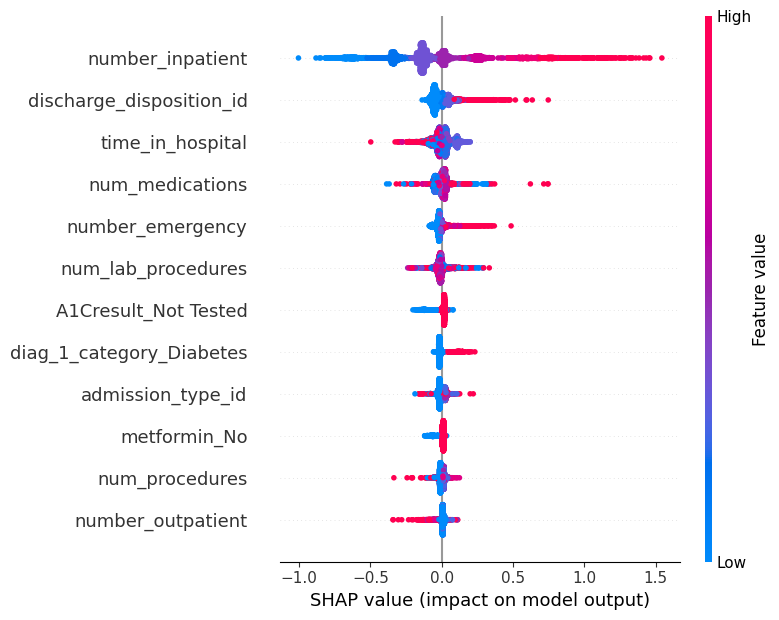

In [4]:
shap.summary_plot(shap_values, X_test, max_display=12)

## Local Explanations

SHAP waterfall plots for two reference patients: the highest-risk and lowest-risk predictions in the test set.

In [5]:
y_proba = model.predict_proba(X_test)[:, 1]
high_risk_idx = int(np.argmax(y_proba))
low_risk_idx = int(np.argmin(y_proba))

print(f"High-risk patient (row {high_risk_idx}): predicted risk = {y_proba[high_risk_idx]:.4f}")
print(f"Low-risk patient (row {low_risk_idx}): predicted risk = {y_proba[low_risk_idx]:.4f}")

High-risk patient (row 1861): predicted risk = 0.7716
Low-risk patient (row 3567): predicted risk = 0.0239


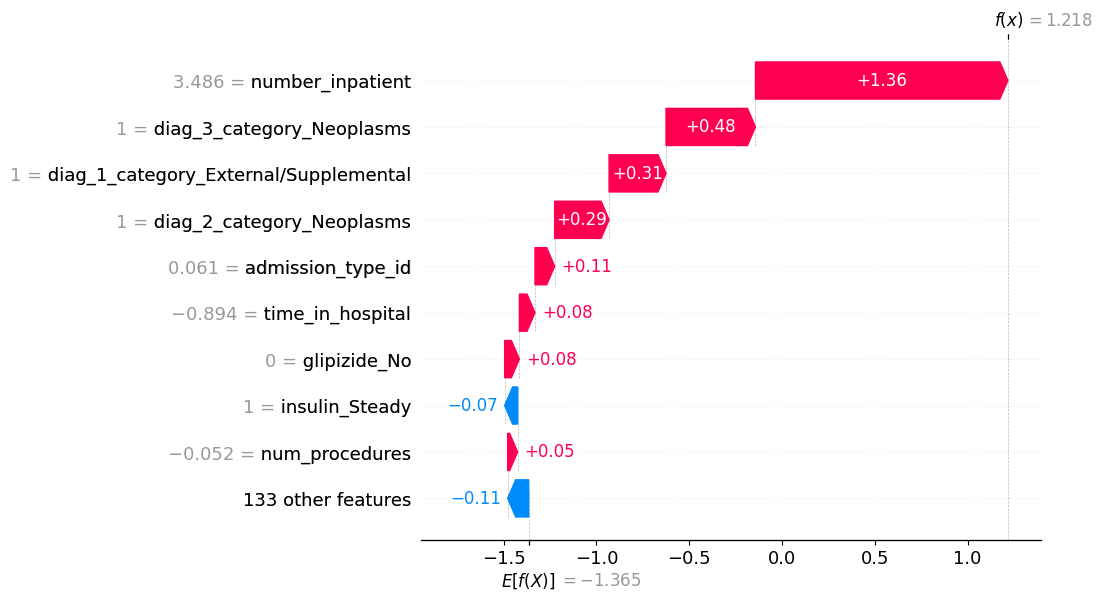

In [6]:
explanation_high = shap.Explanation(
    values=shap_values[high_risk_idx], base_values=explainer.expected_value,
    data=X_test.iloc[high_risk_idx].values, feature_names=X_test.columns.tolist(),
)
shap.plots.waterfall(explanation_high, max_display=10)

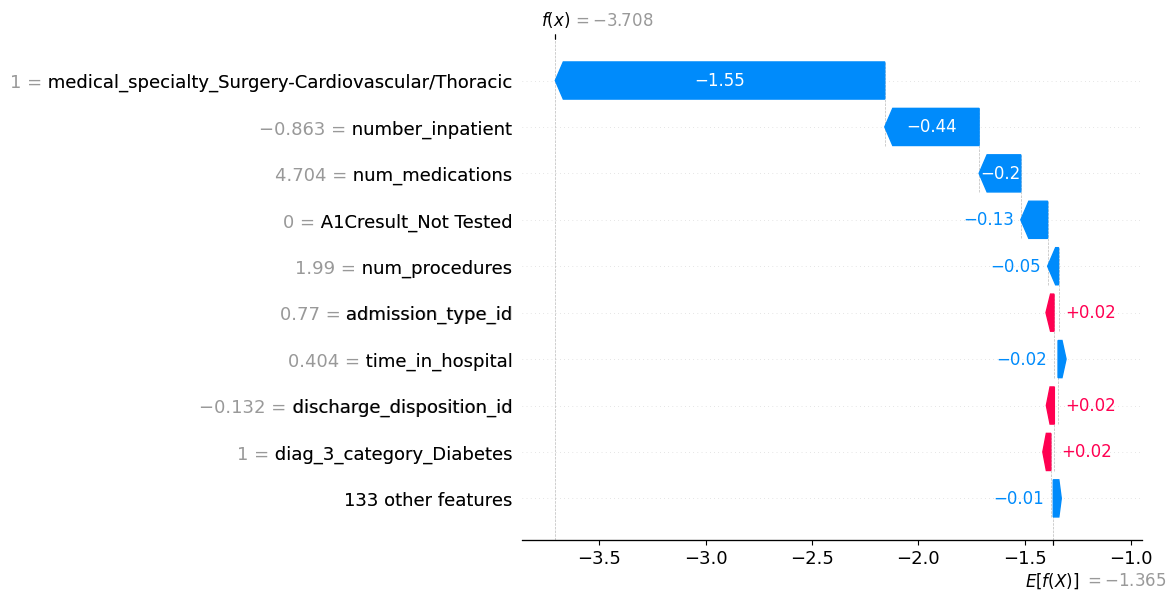

In [7]:
explanation_low = shap.Explanation(
    values=shap_values[low_risk_idx], base_values=explainer.expected_value,
    data=X_test.iloc[low_risk_idx].values, feature_names=X_test.columns.tolist(),
)
shap.plots.waterfall(explanation_low, max_display=10)

## Comparison with LIME

LIME explanations for the same two patients are generated separately in `src/modeling/lime_analysis.py`
(see `reports/lime_local_high_risk.png` and `reports/lime_local_low_risk.png`). Notably, LIME's local linear
surrogate diverged from SHAP on the high-risk patient — LIME's top features were dominated by sparse
`medical_specialty` one-hot indicators rather than `number_inpatient`, illustrating a known limitation of
local-linear approximation methods on high-cardinality one-hot feature spaces. See the Model Card for full discussion.

## Counterfactual Explanations

See `src/modeling/counterfactual.py` and `reports/counterfactual_explanations_readable.txt` for DiceML
counterfactuals on the same high-risk patient — changing actionable features (medication counts, insulin
dosage, procedure counts) dropped predicted risk from 0.77 to ~0.49–0.50 in 3 candidate counterfactuals.